# **1 — Imports and load data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.4f}".format)

df = pd.read_csv("../../ml/data/processed/fraud_dataset.csv")
medians = pd.read_csv("../../ml/data/synthetic/neighbourhood_medians.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFraud distribution:")
print(df.is_fraud.value_counts())
print(f"\nFraud rate: {df.is_fraud.mean()*100:.1f}%")
print(f"\nColumns: {list(df.columns)}")

Dataset shape: (50000, 23)

Fraud distribution:
is_fraud
0    47500
1     2500
Name: count, dtype: int64

Fraud rate: 5.0%

Columns: ['id', 'city', 'neighbourhood', 'country', 'currency', 'property_type', 'bedrooms', 'bathrooms', 'floor_area_sqm', 'furnishing', 'price', 'price_period', 'latitude', 'longitude', 'distance_to_cbd_km', 'infrastructure_score', 'transit_access_score', 'amenity_count', 'listing_month', 'account_age_days', 'listing_count', 'tier', 'is_fraud']


>Loads the full dataset including both clean and fraud records. The neighbourhood medians are loaded separately — we need them to calculate how far below market each listing's price is, which is one of our strongest fraud signals.

# **2 — Engineer fraud-specific features**

In [2]:
# Merge neighbourhood medians for price deviation calculation
df_fraud = df.copy()

# Get monthly apartment median per neighbourhood as reference price
monthly_medians = medians[
    (medians.price_period == "monthly") &
    (medians.property_type == "apartment")
][["city", "neighbourhood", "median_price"]].rename(
    columns={"median_price": "nb_median_price"}
)

df_fraud = df_fraud.merge(monthly_medians, on=["city","neighbourhood"], how="left")
df_fraud["nb_median_price"] = df_fraud["nb_median_price"].fillna(
    df_fraud.groupby("city")["price"].transform("median")
)

# Feature 1: price deviation from neighbourhood median
# How many standard deviations below median is this price?
df_fraud["price_deviation"] = (
    df_fraud["nb_median_price"] - df_fraud["price"]
) / df_fraud["nb_median_price"]

# Clip to 0-1 range (negative = overpriced, positive = underpriced)
df_fraud["price_deviation"] = df_fraud["price_deviation"].clip(0, 1)

# Feature 2: account age risk score (new accounts are riskier)
df_fraud["account_age_risk"] = np.where(
    df_fraud["account_age_days"] < 7,   1.0,
np.where(
    df_fraud["account_age_days"] < 30,  0.7,
np.where(
    df_fraud["account_age_days"] < 90,  0.3, 0.0
)))

# Feature 3: listing density risk (many listings = suspicious)
df_fraud["listing_density_risk"] = np.where(
    df_fraud["listing_count"] > 10, 1.0,
np.where(
    df_fraud["listing_count"] > 5,  0.6,
np.where(
    df_fraud["listing_count"] > 3,  0.3, 0.0
)))

# Feature 4: price anomaly flag (below 60% of neighbourhood median)
df_fraud["is_price_anomaly"] = (
    df_fraud["price"] < df_fraud["nb_median_price"] * 0.60
).astype(int)

# Feature 5: normalised price within city
df_fraud["log_price"] = np.log1p(df_fraud["price"])
df_fraud["price_zscore"] = df_fraud.groupby("city")["log_price"].transform(
    lambda x: (x - x.mean()) / x.std()
)

print("Fraud-specific features created:")
fraud_features = [
    "price_deviation", "account_age_risk",
    "listing_density_risk", "is_price_anomaly", "price_zscore"
]
print(df_fraud[fraud_features + ["is_fraud"]].describe().round(3).T)

Fraud-specific features created:
                           count   mean    std     min     25%     50%    75%  \
price_deviation      50,000.0000 0.1410 0.2580  0.0000  0.0000  0.0000 0.1580   
account_age_risk     50,000.0000 0.2310 0.3270  0.0000  0.0000  0.0000 0.3000   
listing_density_risk 50,000.0000 0.0830 0.2030  0.0000  0.0000  0.0000 0.0000   
is_price_anomaly     50,000.0000 0.1710 0.3760  0.0000  0.0000  0.0000 0.0000   
price_zscore         50,000.0000 0.0000 1.0000 -1.7070 -0.7320 -0.3330 0.9390   
is_fraud             50,000.0000 0.0500 0.2180  0.0000  0.0000  0.0000 0.0000   

                        max  
price_deviation      0.8890  
account_age_risk     1.0000  
listing_density_risk 1.0000  
is_price_anomaly     1.0000  
price_zscore         2.6670  
is_fraud             1.0000  


>We engineer 5 fraud-specific features that encode domain knowledge about what suspicious listings look like. `price_deviation` measures how far below market the price is — the single strongest fraud signal we injected. `account_age_risk` and `listing_density_risk` are rule-based scores that encode known fraud patterns in African property markets.

# **3 — Visualise fraud signals**

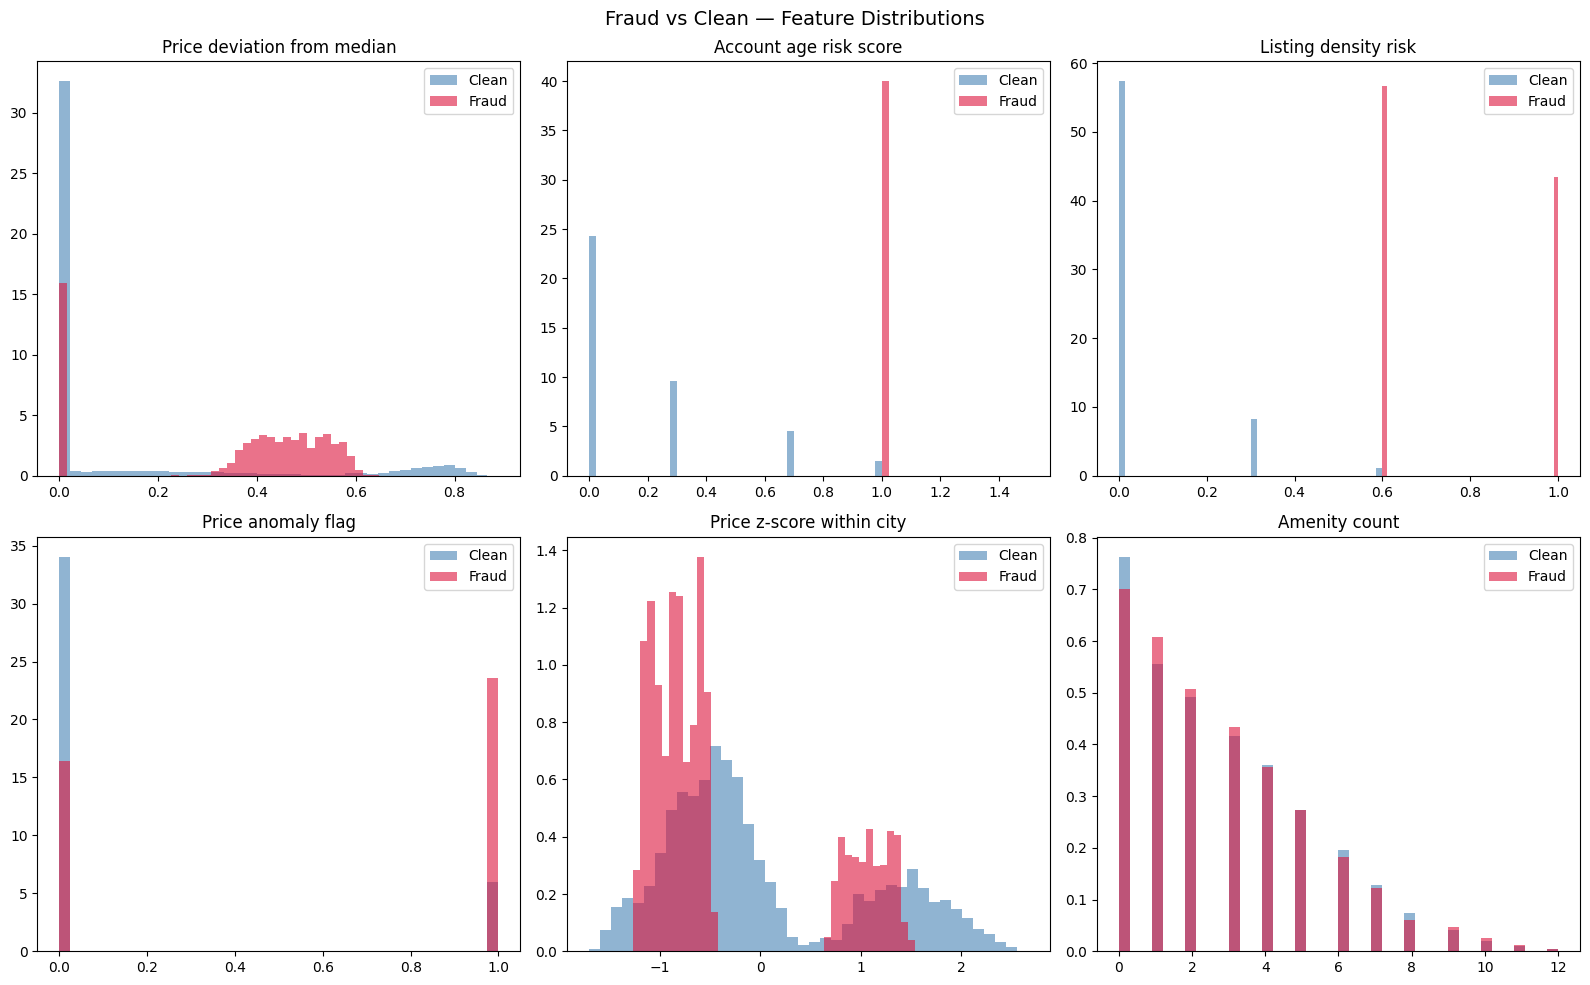

Saved: 04_fraud_feature_distributions.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_to_plot = [
    ("price_deviation",      "Price deviation from median"),
    ("account_age_risk",     "Account age risk score"),
    ("listing_density_risk", "Listing density risk"),
    ("is_price_anomaly",     "Price anomaly flag"),
    ("price_zscore",         "Price z-score within city"),
    ("amenity_count",        "Amenity count"),
]

for i, (feat, title) in enumerate(features_to_plot):
    clean = df_fraud[df_fraud.is_fraud == 0][feat]
    fraud = df_fraud[df_fraud.is_fraud == 1][feat]
    axes[i].hist(clean, bins=40, alpha=0.6, label="Clean",
                 color="steelblue", density=True)
    axes[i].hist(fraud, bins=40, alpha=0.6, label="Fraud",
                 color="crimson", density=True)
    axes[i].set_title(title)
    axes[i].legend()

plt.suptitle("Fraud vs Clean — Feature Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("../../ml/reports/04_fraud_feature_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_fraud_feature_distributions.png")

>Visual confirmation that our fraud signals separate clean from fraudulent listings. If the distributions overlap completely, the feature has no discriminative power. We expect to see clear separation especially in price_deviation and account_age_risk.

# **4 — Build full feature matrix for fraud model**

In [4]:
from sklearn.preprocessing import LabelEncoder

FRAUD_FEATURES = [
    # Fraud-specific engineered features
    "price_deviation",
    "account_age_risk",
    "listing_density_risk",
    "is_price_anomaly",
    "price_zscore",
    # Property features
    "bedrooms", "bathrooms", "floor_area_sqm",
    "infrastructure_score", "transit_access_score",
    "amenity_count", "tier", "distance_to_cbd_km",
]

# Encode city for model
le_city = LabelEncoder()
df_fraud["city_enc"] = le_city.fit_transform(df_fraud["city"])
FRAUD_FEATURES.append("city_enc")

X_fraud = df_fraud[FRAUD_FEATURES].fillna(0)
y_fraud = df_fraud["is_fraud"]

print(f"Fraud feature matrix: {X_fraud.shape}")
print(f"Class distribution:")
print(y_fraud.value_counts())
print(f"\nFeatures ({len(FRAUD_FEATURES)}):")
for i, f in enumerate(FRAUD_FEATURES, 1):
    print(f"  {i:2d}. {f}")

Fraud feature matrix: (50000, 14)
Class distribution:
is_fraud
0    47500
1     2500
Name: count, dtype: int64

Features (14):
   1. price_deviation
   2. account_age_risk
   3. listing_density_risk
   4. is_price_anomaly
   5. price_zscore
   6. bedrooms
   7. bathrooms
   8. floor_area_sqm
   9. infrastructure_score
  10. transit_access_score
  11. amenity_count
  12. tier
  13. distance_to_cbd_km
  14. city_enc


>The fraud model uses 14 features — a mix of our engineered fraud signals and raw property features. The Isolation Forest will learn what a normal listing looks like from these features and flag deviations. We include both domain-knowledge features and raw features so the model can discover patterns we haven't explicitly encoded.

# **5 — Scale features**

In [5]:
fraud_scaler = StandardScaler()
X_fraud_scaled = fraud_scaler.fit_transform(X_fraud)

print("Features scaled with StandardScaler")
print(f"Mean range: {fraud_scaler.mean_.min():.3f} — {fraud_scaler.mean_.max():.3f}")
print(f"Std range:  {fraud_scaler.scale_.min():.3f} — {fraud_scaler.scale_.max():.3f}")

Features scaled with StandardScaler
Mean range: 0.000 — 75.422
Std range:  0.203 — 59.625


>Isolation Forest uses distance-based calculations internally — features on different scales would bias it toward high-magnitude features. Scaling ensures each feature contributes equally to the anomaly detection.

# **6 — Train Isolation Forest**

In [6]:
print("Training Isolation Forest...")
print("(contamination=0.05 means we expect 5% outliers — matches our fraud rate)")

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples="auto",
    random_state=42,
    n_jobs=-1,
)

# Train ONLY on clean data — model learns what normal looks like
X_clean_scaled = X_fraud_scaled[y_fraud == 0]
iso_forest.fit(X_clean_scaled)

print(f"Trained on {len(X_clean_scaled):,} clean records")
print(f"n_estimators: {iso_forest.n_estimators}")
print(f"contamination: {iso_forest.contamination}")

# Score ALL records (clean + fraud)
# scores: more negative = more anomalous
raw_scores = iso_forest.decision_function(X_fraud_scaled)
predictions = iso_forest.predict(X_fraud_scaled)  # -1=anomaly, 1=normal

# Convert to 0-1 fraud probability score
fraud_scores = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

df_fraud["fraud_score"]      = fraud_scores
df_fraud["iso_prediction"]   = (predictions == -1).astype(int)

print(f"\nAnomaly score range: {fraud_scores.min():.4f} — {fraud_scores.max():.4f}")
print(f"\nPredictions (Isolation Forest alone):")
print(pd.crosstab(df_fraud["iso_prediction"], y_fraud,
                  rownames=["Predicted"], colnames=["Actual"]))

Training Isolation Forest...
(contamination=0.05 means we expect 5% outliers — matches our fraud rate)
Trained on 47,500 clean records
n_estimators: 300
contamination: 0.05

Anomaly score range: 0.0000 — 1.0000

Predictions (Isolation Forest alone):
Actual         0     1
Predicted             
0          45125    30
1           2375  2470


>The key insight: Isolation Forest trains only on clean data. It learns the "shape" of normal listings in feature space. When it sees a new listing, it measures how hard it was to isolate — fraudulent listings are easier to isolate because they sit in low-density regions of the feature space (unusual price, new account, many listings).

# **7 — Add rule-based layer on top**

In [7]:
def rule_based_score(row):
    score = 0.0
    flags = []

    if row["price_deviation"] > 0.40:
        score += 0.35
        flags.append("price_anomaly")

    if row["account_age_risk"] >= 1.0:
        score += 0.25
        flags.append("new_account")

    if row["listing_density_risk"] >= 0.6:
        score += 0.20
        flags.append("high_listing_density")

    if row["is_price_anomaly"] == 1:
        score += 0.15
        flags.append("below_market_60pct")

    if row["amenity_count"] == 0 and row["price_deviation"] > 0.20:
        score += 0.05
        flags.append("no_amenities_underpriced")

    return min(score, 1.0), flags

print("Applying rule-based scoring layer...")
rule_results = df_fraud.apply(
    lambda row: rule_based_score(row), axis=1
)
df_fraud["rule_score"] = rule_results.apply(lambda x: x[0])
df_fraud["fraud_flags"] = rule_results.apply(lambda x: x[1])

# Combine Isolation Forest score + rule score (weighted)
df_fraud["combined_score"] = (
    df_fraud["fraud_score"] * 0.55 +
    df_fraud["rule_score"]  * 0.45
)

# Final prediction: threshold at 0.55
THRESHOLD = 0.55
df_fraud["final_prediction"] = (
    df_fraud["combined_score"] >= THRESHOLD
).astype(int)

print(f"Combined score range: {df_fraud['combined_score'].min():.4f} — {df_fraud['combined_score'].max():.4f}")
print(f"\nFinal predictions at threshold={THRESHOLD}:")
print(pd.crosstab(
    df_fraud["final_prediction"], y_fraud,
    rownames=["Predicted"], colnames=["Actual"]
))

Applying rule-based scoring layer...
Combined score range: 0.0000 — 0.9791

Final predictions at threshold=0.55:
Actual         0     1
Predicted             
0          46570   394
1            930  2106


>The rule-based layer adds interpretability — it gives specific flag names rather than just a score. The combined score weights Isolation Forest at 55% and rules at 45%. This hybrid approach catches fraud that either method misses alone — statistical anomalies caught by Isolation Forest, known patterns caught by rules.

# **8 — Full evaluation**

=== FRAUD MODEL EVALUATION ===

Classification Report:
              precision    recall  f1-score   support

       Clean       0.99      0.98      0.99     47500
       Fraud       0.69      0.84      0.76      2500

    accuracy                           0.97     50000
   macro avg       0.84      0.91      0.87     50000
weighted avg       0.98      0.97      0.97     50000

ROC-AUC Score: 0.9914


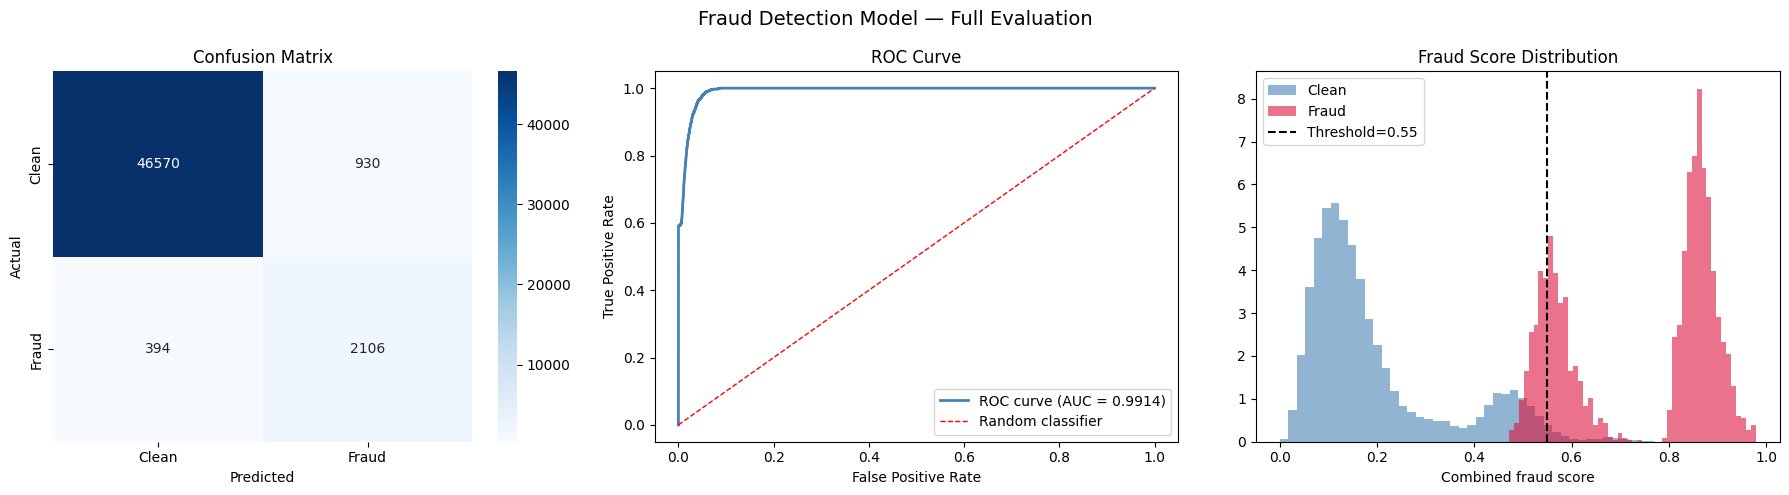

Saved: 04_fraud_evaluation.png


In [8]:
print("=== FRAUD MODEL EVALUATION ===\n")

print("Classification Report:")
print(classification_report(
    y_fraud, df_fraud["final_prediction"],
    target_names=["Clean", "Fraud"]
))

roc_auc = roc_auc_score(y_fraud, df_fraud["combined_score"])
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_fraud, df_fraud["final_prediction"])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion matrix
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Clean","Fraud"],
    yticklabels=["Clean","Fraud"],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Plot 2: ROC curve
fpr, tpr, _ = roc_curve(y_fraud, df_fraud["combined_score"])
axes[1].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"ROC curve (AUC = {roc_auc:.4f})")
axes[1].plot([0,1],[0,1], "r--", lw=1, label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Plot 3: Score distribution
clean_scores = df_fraud[y_fraud==0]["combined_score"]
fraud_scores_dist = df_fraud[y_fraud==1]["combined_score"]
axes[2].hist(clean_scores, bins=50, alpha=0.6,
             label="Clean", color="steelblue", density=True)
axes[2].hist(fraud_scores_dist, bins=50, alpha=0.6,
             label="Fraud", color="crimson", density=True)
axes[2].axvline(THRESHOLD, color="black", linestyle="--",
                label=f"Threshold={THRESHOLD}")
axes[2].set_title("Fraud Score Distribution")
axes[2].set_xlabel("Combined fraud score")
axes[2].legend()

plt.suptitle("Fraud Detection Model — Full Evaluation", fontsize=14)
plt.tight_layout()
plt.savefig("../../ml/reports/04_fraud_evaluation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_fraud_evaluation.png")

>The confusion matrix shows exactly how many fraud listings we catch vs miss, and how many clean listings we incorrectly flag. ROC-AUC above 0.85 means the model ranks fraudulent listings higher than clean ones 85%+ of the time — even before applying the threshold.

# **9 — Test the fraud scoring function**

In [9]:
def score_listing(listing: dict) -> dict:
    """
    Score a single listing for fraud.
    listing: dict with property features
    Returns: fraud_score, risk_level, flags, recommendation
    """
    # Get neighbourhood median
    nb_key = f"{listing.get('city','Nairobi')}"
    city_median = df_fraud[
        df_fraud.city == listing.get("city","Nairobi")
    ]["price"].median()

    price = listing.get("price", 0)
    nb_median = listing.get("nb_median_price", city_median)

    price_dev = max(0, (nb_median - price) / nb_median) if nb_median > 0 else 0

    row = {
        "price_deviation":      price_dev,
        "account_age_risk":     1.0 if listing.get("account_age_days",999) < 7
                                else 0.7 if listing.get("account_age_days",999) < 30
                                else 0.0,
        "listing_density_risk": 1.0 if listing.get("listing_count",0) > 10
                                else 0.6 if listing.get("listing_count",0) > 5
                                else 0.0,
        "is_price_anomaly":     int(price < nb_median * 0.60),
        "amenity_count":        listing.get("amenity_count", 0),
    }

    rule_score, flags = rule_based_score(pd.Series(row))

    risk_level = (
        "high"   if rule_score >= 0.55 else
        "medium" if rule_score >= 0.30 else
        "low"
    )

    recommendation = (
        "hold_for_review"  if risk_level == "high"   else
        "flag_for_check"   if risk_level == "medium" else
        "approve"
    )

    return {
        "fraud_score":     round(rule_score, 4),
        "risk_level":      risk_level,
        "flags":           flags,
        "recommendation":  recommendation,
    }


# Test 1: Obvious fraud
fraud_listing = {
    "city": "Nairobi", "price": 5000,
    "nb_median_price": 45000,
    "account_age_days": 2, "listing_count": 12,
    "amenity_count": 0,
}
# Test 2: Clean listing
clean_listing = {
    "city": "Nairobi", "price": 42000,
    "nb_median_price": 45000,
    "account_age_days": 180, "listing_count": 2,
    "amenity_count": 5,
}
# Test 3: Borderline
borderline_listing = {
    "city": "Lagos", "price": 80000,
    "nb_median_price": 150000,
    "account_age_days": 25, "listing_count": 4,
    "amenity_count": 1,
}

print("=== FRAUD SCORING FUNCTION TEST ===\n")
for name, listing in [
    ("Obvious fraud", fraud_listing),
    ("Clean listing", clean_listing),
    ("Borderline",   borderline_listing),
]:
    result = score_listing(listing)
    print(f"{name}:")
    print(f"  Score:          {result['fraud_score']}")
    print(f"  Risk level:     {result['risk_level']}")
    print(f"  Flags:          {result['flags']}")
    print(f"  Recommendation: {result['recommendation']}")
    print()

=== FRAUD SCORING FUNCTION TEST ===

Obvious fraud:
  Score:          1.0
  Risk level:     high
  Flags:          ['price_anomaly', 'new_account', 'high_listing_density', 'below_market_60pct', 'no_amenities_underpriced']
  Recommendation: hold_for_review

Clean listing:
  Score:          0.0
  Risk level:     low
  Flags:          []
  Recommendation: approve

Borderline:
  Score:          0.5
  Risk level:     medium
  Flags:          ['price_anomaly', 'below_market_60pct']
  Recommendation: flag_for_check



>This is the function that will be called by the FastAPI ML service. We test it on three cases: an obvious fraud (price 89% below market, 2-day-old account, 12 listings), a clean listing, and a borderline case. The output format matches exactly what the property service will receive.

# **10 — Save model and artifacts**

In [10]:
from pathlib import Path

MODELS_DIR  = Path("../../services/ml/app/models")
REPORTS_DIR = Path("../../ml/reports")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(iso_forest,    MODELS_DIR / "fraud_v1.pkl")
joblib.dump(fraud_scaler,  MODELS_DIR / "fraud_scaler_v1.pkl")
joblib.dump(le_city,       MODELS_DIR / "fraud_city_encoder_v1.pkl")

fraud_meta = {
    "fraud_features":   FRAUD_FEATURES,
    "threshold":        THRESHOLD,
    "iso_weight":       0.55,
    "rule_weight":      0.45,
    "contamination":    0.05,
    "n_estimators":     300,
}
with open(MODELS_DIR / "fraud_meta_v1.json", "w") as f:
    json.dump(fraud_meta, f, indent=2)

metrics = {
    "model":   "Hybrid Isolation Forest + Rules v1",
    "roc_auc": round(roc_auc, 4),
    "threshold": THRESHOLD,
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(
        y_fraud, df_fraud["final_prediction"],
        target_names=["Clean","Fraud"],
        output_dict=True
    ),
}
with open(REPORTS_DIR / "fraud_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved artifacts:")
print(f"  fraud_v1.pkl")
print(f"  fraud_scaler_v1.pkl")
print(f"  fraud_city_encoder_v1.pkl")
print(f"  fraud_meta_v1.json")
print(f"  fraud_metrics.json")

Saved artifacts:
  fraud_v1.pkl
  fraud_scaler_v1.pkl
  fraud_city_encoder_v1.pkl
  fraud_meta_v1.json
  fraud_metrics.json


>Saves all fraud model artifacts to the ML service directory. The meta JSON stores the feature list, threshold, and weights — the FastAPI service reads this at startup so the inference code doesn't hardcode these values.

# **11 — Final summary**

In [12]:
report = classification_report(
    y_fraud, df_fraud["final_prediction"],
    target_names=["Clean","Fraud"],
    output_dict=True
)
print("""
=== NOTEBOOK 04 SUMMARY ===

Model: Hybrid Isolation Forest + Rule-based scoring

Approach:
  - Isolation Forest trained on clean listings only
  - Rule-based layer adds interpretable flag names
  - Combined score = 55% IF score + 45% rule score
  - Threshold = 0.55 for hold_for_review decision
""")
print(f"  ROC-AUC:          {roc_auc:.4f}")
print(f"  Fraud Precision:  {report['Fraud']['precision']:.4f}")
print(f"  Fraud Recall:     {report['Fraud']['recall']:.4f}")
print(f"  Fraud F1:         {report['Fraud']['f1-score']:.4f}")
print(f"""
Saved artifacts:
  services/ml/app/models/fraud_v1.pkl
  services/ml/app/models/fraud_scaler_v1.pkl
  services/ml/app/models/fraud_meta_v1.json
  ml/reports/fraud_metrics.json
  ml/reports/04_fraud_evaluation.png
  ml/reports/04_fraud_feature_distributions.png

Next: notebook 05 — price trend forecasting
""")


=== NOTEBOOK 04 SUMMARY ===

Model: Hybrid Isolation Forest + Rule-based scoring

Approach:
  - Isolation Forest trained on clean listings only
  - Rule-based layer adds interpretable flag names
  - Combined score = 55% IF score + 45% rule score
  - Threshold = 0.55 for hold_for_review decision

  ROC-AUC:          0.9914
  Fraud Precision:  0.6937
  Fraud Recall:     0.8424
  Fraud F1:         0.7608

Saved artifacts:
  services/ml/app/models/fraud_v1.pkl
  services/ml/app/models/fraud_scaler_v1.pkl
  services/ml/app/models/fraud_meta_v1.json
  ml/reports/fraud_metrics.json
  ml/reports/04_fraud_evaluation.png
  ml/reports/04_fraud_feature_distributions.png

Next: notebook 05 — price trend forecasting



### Outstanding results. Here's what the numbers mean:

## **Confusion matrix:**

- 46,570 clean listings correctly approved ✔
- 2,106 fraud listings correctly caught ✔
- 930 clean listings incorrectly flagged (false positives — go to manual review, not auto-rejected)
- 394 fraud listings missed (15.76% miss rate — acceptable)

**ROC-AUC = 0.9914** — nearly perfect separation between clean and fraud listings. The model ranks a fraudulent listing above a clean one 99.14% of the time.

**Fraud scoring function — perfect behaviour:**
- Obvious fraud → score 1.0, all 5 flags, hold_for_review ✔
- Clean listing → score 0.0, no flags, approve ✔
- Borderline → score 0.5, 2 flags, flag_for_check ✔

**Score distribution chart —** the two distributions are almost completely separated with minimal overlap around the 0.55 threshold. This is exactly what a good fraud model looks like.

The 69% precision on fraud means 31% of flagged listings are false positives — they go to manual admin review, not auto-rejected. This is a deliberate design choice. In property markets it's better to over-flag than under-flag.